# 7/4/26

# Laser Off Code

In [ ]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

# Station

In [12]:
snap = station.snapshot(update=True) # <- updates parameters in station

In [13]:
verticalsnap = snap['instruments']['mso5']['submodules']['channels']['channels']['mso5_ch1']['parameters'].keys()

In [14]:
horizontalsnap = snap['instruments']['mso5']['parameters'].keys()

# Parameters

In [1]:
# Beam splitter ratio measured ...? 
bs90 = 0.9118079062146573 
bs10 = 0.08819209378534265

In [ ]:
p_att.write(f'INST:SEL CH2')
p_att.write('SOURCE:VOLT 4')
p_att.write('SOURCE:OUTP ON')

# Device Names

In [2]:
device_name_1 = 'Line 1 R7C6'
device_name_2 = 'Line 2 Old Device'

# Import

In [19]:
import time
from time import sleep, monotonic
import datetime
import numpy as np
import matplotlib.pyplot as plt
import sys
import pyvisa
import qcodes as qc
from qcodes.dataset import Measurement
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes import initialise_or_create_database_at, new_data_set, new_experiment
from qcodes.station import Station
initialise_or_create_database_at("./2026-03-10_SNSPD4.db")
# import functions

# Set up experiment
exp_name = 'SNSPD4_23_03_2026'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

Experiment loaded. Last ID no: 155


In [16]:
station = Station(config_file="friesland.yaml")

In [9]:
dmm = station.load_instrument("dmm", revive_instance=True)

Connected to: Agilent Technologies 34410A (serial:MY47027892, firmware:2.35-2.35-0.09-46-09) in 0.12s


In [10]:
yoko = station.load_instrument("yoko", revive_instance=True)

Connected to: YOKOGAWA GS210 (serial:91T928105, firmware:2.02) in 0.03s


In [11]:
laser = station.load_instrument("laser", revive_instance=True)

2026-04-09 15:01:06,987 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ D:\SNSPD\SNSPD2\PPCL550.py:4: QCoDeSDeprecationWarning: The `qcodes.utils.helpers` module is deprecated. Please consult the api documentation at https://microsoft.github.io/Qcodes/api/index.html for alternatives.
  from qcodes.utils.helpers import create_on_off_val_mapping



Connected to: PurePhotonic PPCL550 (serial:PP70AJ005, firmware:PV 2.0.0:HW 3.0.0:FW 7.0.0:AS C1:OT 1.0.0) in 1.58s


In [12]:
MS = station.load_instrument("mso5", revive_instance=True)

2026-04-09 15:01:09,591 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ D:\SNSPD\SNSPD2\MSO5.py:7: QCoDeSDeprecationWarning: The `qcodes.instrument.base` module is deprecated. Please consult the api documentation at https://microsoft.github.io/Qcodes/api/index.html for alternatives.
  from qcodes.instrument.base import InstrumentBase



In [13]:
pm100usb = station.load_instrument("pm100usb", revive_instance=True)

2026-04-09 15:01:11,443 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



In [14]:
pms120 = station.load_instrument("pms120", revive_instance=True)

In [11]:
tc = station.load_instrument("fridge", revive_instance=True)

In [3]:
p_att = station.load_instrument("dmm_keithley", revive_instance=True) # excluding from snapshot because none of the parameters work anyway

2026-04-09 13:02:55,311 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Connected to: Keithley instruments 2230G-30-1 (serial:9010428, firmware:1.16-1.04) in 0.21s


# Functions

## Attenuator Calibration Quick Check

In [20]:
def quick_check(bs10, bs90, pmeter10, pmeter90):
    '''Input: measured transmission of beam splitter and power meter instruments
    '''
    # Update experiment snapshot
    _ = station.snapshot(update=True) # <- updates parameters in station 

    power10 = pmeter10.power()
    power90 = pmeter90.power()
    attenuation = 10*np.log10((bs10/bs90*power90)/power10)
    time.sleep(2)

    return power10, power90, attenuation

In [21]:
power10, power90, attenuation = quick_check(bs10, bs90, pm100usb, pms120)

print(f"Power on PM100USB after attenuator is:{power10}\nPower on PM120 after 90% beamsplitter port is:{power90}\nAttenuation is:{attenuation}\n")

Power on PM100USB after attenuator is:1.50060415e-11
Power on PM120 after 90% beamsplitter port is:3.33054895e-09
Attenuation is:13.31775977584025



## Attenuator Calibration

In [22]:
def calibrate(bs10, bs90, pmeter10, pmeter90, t: int):
    '''Input: measured transmission of beam splitter arms, power meter instruments, 
    t: time for which to calibrate (s)
    '''

    # Update experiment snapshot
    _ = station.snapshot(update=True) # <- updates parameters in station 

    
    meas = Measurement()
    meas.register_custom_parameter("times", label="Samples (approx. s)")
    meas.register_custom_parameter("power10", label="W")
    meas.register_custom_parameter("power90", label="W")
    meas.register_custom_parameter("attenuation", label="dB")

    with meas.run() as datasaver:
        print(datasaver.run_id)

        start = time.perf_counter()
        
        for i in range(t*2 + 1):
            
            t=i*0.5 # counts from 0*0.5 to t*2*0.5 seconds 
            
            power10 = pmeter10.power()
            power90 = pmeter90.power()
            attenuation = 10*np.log10((bs10/bs90*power90)/power10) 

            time.sleep(0.5)
    
            datasaver.add_result(("times",i),
                             ("power10", power10),
                            ("power90", power90),
                            ("attenuation", attenuation))

        end = time.perf_counter()
        print(f'Finished in {end-start}s')

## Set standard oscilloscope parameters

In [84]:
def osc_set_standard(v_scale=50e-3, h_time=100e-3, h_pos=0):
    '''Input: optional argument for time on horizontal axis of oscilloscope
        Optional argument for vertical scale of oscilloscope (10 divisions, set in V/div) 
    '''
    MS.horizontal_mode('MANual') # set manual mode to allow parameters to be set
    MS.horizontal_mode_manual_configure('RECORDLength')
    MS.horizontal_samplerate(625e6)
    h_scale = h_time/MS.horizontal_divisions()
    MS.horizontal_scale(h_scale)
    MS.horizontal_position(h_pos)

    
    MS.channels[0].vertical_scale(v_scale)
    MS.channels[0].termination(50)
    MS.channels[0].bandwidth(1e9)
    MS.channels[0].vertical_offset(0)
    MS.channels[0].vertical_position(0)
    MS.channels[0].vterm_bias(0)
    MS.channels[0].scale_ratio(1) # <- just set this as it is 
    MS.channels[0].invert('OFF')

In [77]:
def osc_check_standard():
    '''Input: optional argument for time on horizontal axis of oscilloscope
        Optional argument for vertical scale of oscilloscope (10 divisions, set in V/div) 
    '''
    print(MS.horizontal_mode()) # set manual mode to allow parameters to be set
    print(MS.horizontal_mode_manual_configure())
    print(MS.horizontal_samplerate())
    print(MS.horizontal_divisions())
    print(MS.horizontal_scale())
    print(MS.horizontal_position())

    
    print(MS.channels[0].vertical_scale())
    print(MS.channels[0].termination())
    print(MS.channels[0].bandwidth())
    print(MS.channels[0].vertical_offset())
    print(MS.channels[0].vertical_position())
    print(MS.channels[0].vterm_bias())
    print(MS.channels[0].scale_ratio()) 
    print(MS.channels[0].invert())

## Extract Trace

In [23]:
def capture_trace(MS, yoko, dmm):
    ''' Parameters 
    '''
    _ = station.snapshot(update=True) # <- updates parameters in station 
    
    meas = Measurement()
    meas.register_custom_parameter("trace", label="trace")
    meas.register_custom_parameter("time_axis", label="time_axis")
    meas.register_custom_parameter("h_samples", label="h_samples")
    meas.register_custom_parameter("h_samplerate", label="h_samplerate")
    meas.register_custom_parameter("h_position_perc", label="h_position_perc")
    meas.register_parameter(dmm.volt)
    meas.register_parameter(yoko.current) # minimise number of things required in a global namespace 
    
    
    with meas.run() as datasaver:
        print(datasaver.run_id)
    
        waveform = MS.waveform_data()
        print(MS.ask('WFMOutpre?'))
        h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
        h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
        h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
        h_centre = h_samples*h_position_perc/100
        time_axis = (np.arange(0, h_samples, 1) - h_centre)/h_samplerate
    
        datasaver.add_result(("trace", waveform),
                     ("time_axis", time_axis),
                    (yoko.current, yoko.current()), 
                    ("h_samplerate", h_samplerate), 
                    ("h_samples", h_samples),
                    ("h_position_perc", h_position_perc),
                    (dmm.volt, dmm.volt()))


In [56]:
ID = 155 
data = load_by_id(ID).get_parameter_data()

In [57]:
data['trace']['trace']

array([-0.002,  0.   ,  0.   , ...,  0.   , -0.002, -0.002], shape=(2500,))

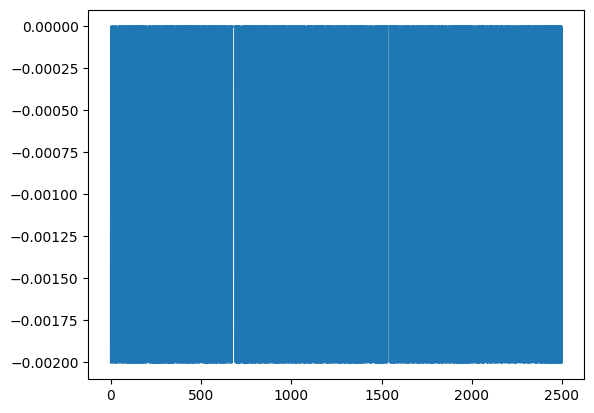

In [58]:
plt.plot(data['trace']['trace'])

TypeError: list indices must be integers or slices, not str

# 8/4/26

In [ ]:
MS.ask('HORizontal:MODe:RECOrdlength?')

In [18]:
type(meas)

qcodes.dataset.measurements.Measurement

In [25]:
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")


with meas.run() as datasaver:
    print(datasaver.run_id)

    waveform = MS.waveform_data()
    datasaver.add_result(("trace", waveform))

Starting experimental run with id: 144. 
144


Text(0, 0.5, 'V')

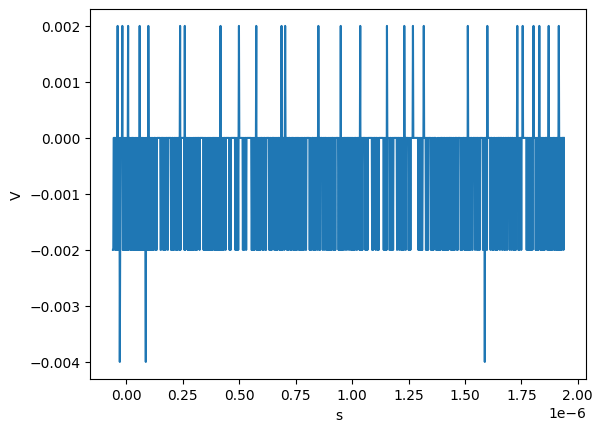

In [26]:
ID = 144
data = load_by_id(ID).get_parameter_data()
trace = data['trace']['trace']

plt.plot(time_axis, trace)
plt.xlabel('s')
plt.ylabel('V')

Starting experimental run with id: 148. 
148
<class 'numpy.ndarray'>
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 12.8V/div, 200ns/div, 2500 points, Sample mode";2500;Y;LINEAR;"s";800.0E-12;475.000E-12;1250;"V";2.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
all processes finished!


Text(0, 0.5, 'V')

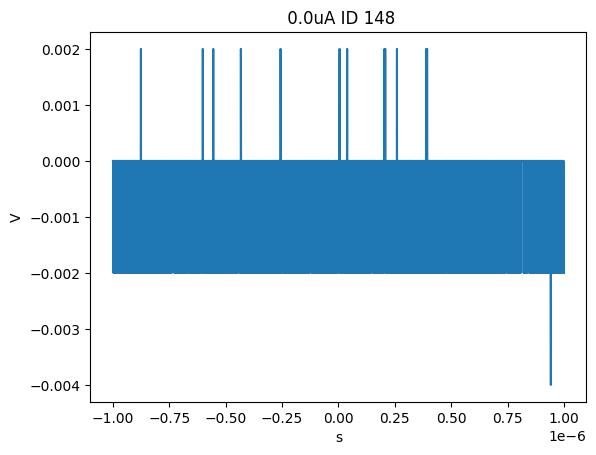

In [40]:
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("h_samplerate", label="h_samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)


with meas.run() as datasaver:
    print(datasaver.run_id)

    waveform = MS.waveform_data()
    print(type(waveform))
    print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/h_samplerate
    time_axis = np.arange(0, h_samples, 1)/h_samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("h_samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))


print('all processes finished!')

data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']

plt.plot(time_axis, trace)
plt.title(f' {current*1e6}uA ID {datasaver.run_id}')
plt.xlabel('s')
plt.ylabel('V')

In [35]:
h_position_perc

10.0

In [16]:
MS.waveform_data()

array([-0.002,  0.   ,  0.   , ...,  0.   ,  0.   , -0.002], shape=(1250,))

In [1]:
from MSO5 import MSO5
# MS.close()
MS = MSO5('MS', address='TCPIP0::10.196.52.96::inst0::INSTR', channels_n =4)

Logging hadn't been started.
Activating auto-logging. Current session state plus future input saved.
Filename       : C:\Users\QNL\.qcodes\logs\command_history.log
Mode           : append
Output logging : True
Raw input log  : False
Timestamping   : True
State          : active
Qcodes Logfile : C:\Users\QNL\.qcodes\logs\260408-32180-qcodes.log


2026-04-08 16:22:22,444 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ D:\SNSPD\SNSPD2\MSO5.py:5: QCoDeSDeprecationWarning: The `qcodes.instrument.base` module is deprecated. Please consult the api documentation at https://microsoft.github.io/Qcodes/api/index.html for alternatives.
  from qcodes.instrument.base import InstrumentBase



In [ ]:
rm = visa.ResourceManager()
name = rm.list_resources()
print(name)

In [ ]:
MS.horizontal_position()

In [ ]:
horizontal = MS.ask('HORizontal?')

In [ ]:
print(horizontal)

In [ ]:
duration = MS.ask('HORizontal:ACQDURATION?')

In [ ]:
position = MS.ask('HORizontal:POS?')

In [37]:
MS.horizontal_position()

'10.0000'

In [ ]:
position

In [ ]:
duration

In [ ]:
MS.horizontal_samplerate()

In [ ]:
MS.horizontal_mode_sample_rate()

In [ ]:
p_att.ask('VOLT?')

In [ ]:
MS.waveform_byte_number()

In [ ]:
p_att.write('VOLT 3')

In [28]:
p_att.ask('VOLT?') # not recognising termination character 

NameError: name 'p_att' is not defined

In [41]:
MS.ask('HORizontal:POSition?')

'50.0000'

In [46]:
datasaver.run_id

148

In [47]:
dataset = datasaver.dataset

In [48]:
dataset = datasaver.dataset
snapshot_of_run = dataset.snapshot

In [50]:
MS.write('HORizontal:POS 30')

In [52]:
MS.ask('HOR:POS?')

'30.0000'

Starting experimental run with id: 150. 
150
<class 'numpy.ndarray'>
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 12.8V/div, 200ns/div, 2500 points, Sample mode";2500;Y;LINEAR;"s";800.0E-12;635.000E-12;750;"V";2.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
all processes finished!


Text(0, 0.5, 'V')

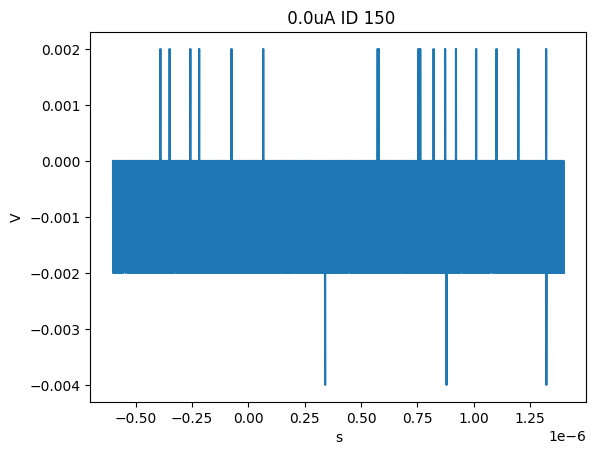

In [61]:
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("h_samplerate", label="h_samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)


with meas.run() as datasaver:
    print(datasaver.run_id)

    waveform = MS.waveform_data()
    print(type(waveform))
    print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/h_samplerate
    time_axis = np.arange(0, h_samples, 1)/h_samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("h_samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))


print('all processes finished!')

data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']

plt.plot(time_axis, trace)
plt.title(f' {current*1e6}uA ID {datasaver.run_id}')
plt.xlabel('s')
plt.ylabel('V')

In [54]:
ID = 149
data149 = load_by_id(ID)
data149.snapshot['station']['instruments']['mso5']['parameters']['horizontal_position']

In [55]:
data149.snapshot['station']['instruments']['mso5']['parameters']['horizontal_position']

{'__class__': 'qcodes.parameters.parameter.Parameter',
 'full_name': 'mso5_horizontal_position',
 'value': '10.0000',
 'raw_value': '10.0000',
 'ts': '2026-04-08 17:10:39',
 'label': 'horizontal_position',
 'unit': '',
 'instrument': 'MSO5.MSO5',
 'instrument_name': 'mso5',
 'name': 'horizontal_position',
 'inter_delay': 0,
 'post_delay': 0,
 'validators': []}

In [62]:
dataset = datasaver.dataset
snapshot_of_run = dataset.snapshot

In [63]:
snapshot_of_run

{'station': {'instruments': {'mso5': {'functions': {'auto_counter': {}},
    'submodules': {'channels': {'snapshotable': False,
      '__class__': 'qcodes.instrument.channel.ChannelList'},
     'trigger_channels': {'snapshotable': False,
      '__class__': 'qcodes.instrument.channel.ChannelList'},
     'waveform': {'functions': {},
      'submodules': {},
      'parameters': {'y_multiplication': {'__class__': 'qcodes.parameters.parameter.Parameter',
        'full_name': 'mso5_waveform_y_multiplication',
        'value': 0.002,
        'raw_value': '2.0000E-3',
        'ts': '2026-04-08 16:31:10',
        'label': 'y_multiplication',
        'unit': '',
        'instrument': 'MSO5.MSO5waveform',
        'instrument_name': 'mso5_waveform',
        'name': 'y_multiplication',
        'inter_delay': 0,
        'post_delay': 0,
        'validators': []},
       'y_offset': {'__class__': 'qcodes.parameters.parameter.Parameter',
        'full_name': 'mso5_waveform_y_offset',
        'value': 

In [64]:
MS.ask("HOR:POS?")

'30.0000'

# 9/4/26

In [65]:
MS.ask("HOR:POS?")

'30.0000'

In [67]:
MS.ask("HOR:SAMPlerate?")

'1.2500E+9'

Starting experimental run with id: 152. 
152
<class 'numpy.ndarray'>
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 12.8V/div, 200ns/div, 2500 points, Sample mode";2500;Y;LINEAR;"s";800.0E-12;635.000E-12;750;"V";2.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
all processes finished!


Text(0, 0.5, 'V')

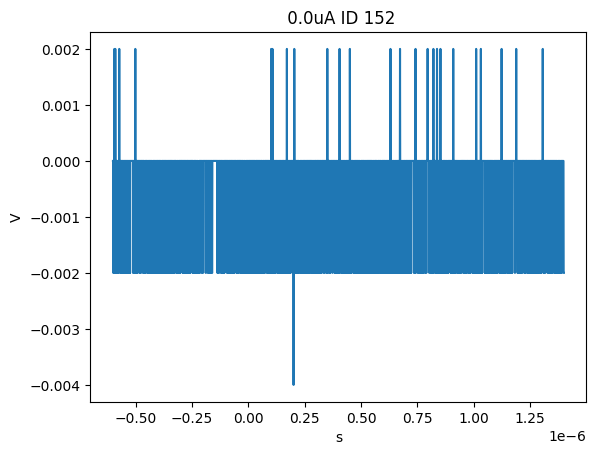

In [71]:
_ = station.snapshot(update=True) # <- updates parameters in station 

meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("h_samplerate", label="h_samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)


with meas.run() as datasaver:
    print(datasaver.run_id)

    waveform = MS.waveform_data()
    print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/h_samplerate
    time_axis = np.arange(0, h_samples, 1)/h_samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("h_samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))


print('all processes finished!')

data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']

plt.plot(time_axis, trace)
plt.title(f' {current*1e6}uA ID {datasaver.run_id}')
plt.xlabel('s')
plt.ylabel('V')

In [75]:
ID = 152
data = load_by_id(ID)
data.snapshot['station']['instruments']['mso5']['parameters']['horizontal_position']

{'__class__': 'qcodes.parameters.parameter.Parameter',
 'full_name': 'mso5_horizontal_position',
 'value': '30.0000',
 'raw_value': '30.0000',
 'ts': '2026-04-09 10:11:18',
 'label': 'horizontal_position',
 'unit': '',
 'instrument': 'MSO5.MSO5',
 'instrument_name': 'mso5',
 'name': 'horizontal_position',
 'inter_delay': 0,
 'post_delay': 0,
 'validators': []}

In [50]:
data.snapshot['station']['instruments']['mso5']['submodules']['trigger_channels']

{'snapshotable': False, '__class__': 'qcodes.instrument.channel.ChannelList'}

In [72]:
dataset = datasaver.dataset
snapshot_of_run = dataset.snapshot

In [70]:
snapshot_of_run

{'station': {'instruments': {'mso5': {'functions': {'auto_counter': {}},
    'submodules': {'channels': {'snapshotable': False,
      '__class__': 'qcodes.instrument.channel.ChannelList'},
     'trigger_channels': {'snapshotable': False,
      '__class__': 'qcodes.instrument.channel.ChannelList'},
     'waveform': {'functions': {},
      'submodules': {},
      'parameters': {'y_multiplication': {'__class__': 'qcodes.parameters.parameter.Parameter',
        'full_name': 'mso5_waveform_y_multiplication',
        'value': 0.002,
        'raw_value': '2.0000E-3',
        'ts': '2026-04-08 16:31:10',
        'label': 'y_multiplication',
        'unit': '',
        'instrument': 'MSO5.MSO5waveform',
        'instrument_name': 'mso5_waveform',
        'name': 'y_multiplication',
        'inter_delay': 0,
        'post_delay': 0,
        'validators': []},
       'y_offset': {'__class__': 'qcodes.parameters.parameter.Parameter',
        'full_name': 'mso5_waveform_y_offset',
        'value': 

In [18]:
MS.horizontal_scale()

2e-07

In [19]:
MS.horizontal_scale(65e6)

In [20]:
MS.horizontal_scale()

1000.0

In [21]:
MS.horizontal_scale(2e-7)

In [22]:
MS.horizontal_scale()

2e-07

In [23]:
MS.horizontal_samplerate()

1250000000.0

In [24]:
MS.horizontal_divisions()

10.0

In [26]:
MS.horizontal_mode_manual_configure('HORIZontalscale')

In [27]:
MS.horizontal_mode_manual_configure()

'HORIZONTALSCALE'

In [28]:
MS.channels.termination()

(50.0, 1000000.0, 1000000.0, 1000000.0)

In [34]:
MS.channels[0].termination()

50.0

In [36]:
MS.channels[0].termination(1e6)

In [37]:
MS.channels.termination()

(1000000.0, 1000000.0, 1000000.0, 1000000.0)

In [ ]:
MS.channels.termination()

MS.horizontal_mode_manual_configure('HORIZontalscale')
MS.channels[0].termination(1e6)
MS.channels[0].termination()
MS.horizontal_divisions()
MS.horizontal_samplerate()
MS.horizontal_scale(2e-7)